# Cargar dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
#Agregar dataset en esta línea ya sea en drive o manualmente el archivo CSV
df = pd.read_excel('/content/drive/MyDrive/GlobalDataonSustainableEnergy.xlsx')

# Remplazar valores faltantes por la media

# Tratamiento de datos

Valores nulos y 0

In [ ]:
df_limpio = df

print("Valores nulos")
print(df_limpio.isnull().sum())
print("Valores 0")
print((df_limpio == 0).sum())

Valores nulos
Entidad                                                          0
Año                                                              0
Acceso a la electricidad (% de la población)                     0
Acceso a combustibles limpios para cocinar                       8
Capacidad de generación de electricidad renovable per cápita    45
Electricidad a partir de combustibles fósiles (TWh)              0
Electricidad a partir de nuclear (TWh)                           5
Electricidad a partir de renovables (TWh)                        0
Electricidad de baja emisión de carbono (% del total)            1
Consumo de energía primaria per cápita (kWh/persona)             0
Crecimiento del PIB                                             16
PIB per cápita                                                  16
Densidad (P/Km2)                                                 0
Área terrestre (Km2)                                             0
Latitud                                         

In [ ]:
columnas_num = df_limpio.select_dtypes(include=['float64', 'int64']).columns

df_limpio = df.replace(0, np.nan)
df_limpio[columnas_num] = df[columnas_num].fillna(df[columnas_num].mean())

In [ ]:
print(df_limpio.isnull().sum())
print((df_limpio == 0).sum())

Entidad                                                         0
Año                                                             0
Acceso a la electricidad (% de la población)                    0
Acceso a combustibles limpios para cocinar                      0
Capacidad de generación de electricidad renovable per cápita    0
Electricidad a partir de combustibles fósiles (TWh)             0
Electricidad a partir de nuclear (TWh)                          0
Electricidad a partir de renovables (TWh)                       0
Electricidad de baja emisión de carbono (% del total)           0
Consumo de energía primaria per cápita (kWh/persona)            0
Crecimiento del PIB                                             0
PIB per cápita                                                  0
Densidad (P/Km2)                                                0
Área terrestre (Km2)                                            0
Latitud                                                         0
Longitud  

In [ ]:
# Filtrar solo las columnas numéricas (float64 e int64)
df_numerico = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Año'])

# Verificar que las columnas seleccionadas sean numéricas
print("Columnas numéricas seleccionadas:\n", df_numerico.columns)

# Mostrar los tipos de datos de todas las columnas
print("Tipos de datos por columna:\n", df.dtypes)

Columnas numéricas seleccionadas:
 Index(['Acceso a la electricidad (% de la población)',
       'Acceso a combustibles limpios para cocinar',
       'Capacidad de generación de electricidad renovable per cápita',
       'Electricidad a partir de combustibles fósiles (TWh)',
       'Electricidad a partir de nuclear (TWh)',
       'Electricidad a partir de renovables (TWh)',
       'Electricidad de baja emisión de carbono (% del total)',
       'Consumo de energía primaria per cápita (kWh/persona)',
       'Crecimiento del PIB', 'PIB per cápita', 'Densidad (P/Km2)',
       'Área terrestre (Km2)', 'Latitud', 'Longitud'],
      dtype='object')
Tipos de datos por columna:
 Entidad                                                          object
Año                                                               int64
Acceso a la electricidad (% de la población)                    float64
Acceso a combustibles limpios para cocinar                      float64
Capacidad de generación de electri

Calculo estadistico

In [ ]:
# Calcular la media y la desviación estándar de las columnas numéricas
mean = df_numerico.mean()
std = df_numerico.std()

# Mostrar los resultados de la media y desviación estándar
print("Media de las columnas numéricas:\n", mean)
print("Desviación estándar de las columnas numéricas:\n", std)


Media de las columnas numéricas:
 Acceso a la electricidad (% de la población)                        85.378301
Acceso a combustibles limpios para cocinar                          67.547892
Capacidad de generación de electricidad renovable per cápita       169.593411
Electricidad a partir de combustibles fósiles (TWh)                 82.582701
Electricidad a partir de nuclear (TWh)                              13.186982
Electricidad a partir de renovables (TWh)                           40.063448
Electricidad de baja emisión de carbono (% del total)               40.445429
Consumo de energía primaria per cápita (kWh/persona)             24216.289653
Crecimiento del PIB                                                 -4.589277
PIB per cápita                                                   15151.693446
Densidad (P/Km2)                                                   221.293103
Área terrestre (Km2)                                            634640.816092
Latitud                       

# Eliminación outliers


In [ ]:
# Filtrar los valores que están fuera de 3 desviaciones estándar
df_sin_outliers = df_numerico[(df_numerico > (mean - 3 * std)) & (df_numerico < (mean + 3 * std))]

# Reintegrar las columnas no numéricas después de eliminar los outliers
df_final = pd.concat([df_sin_outliers, df[['Año']], df.select_dtypes(exclude=['float64', 'int64'])], axis=1)

# Mostrar el DataFrame final sin los outliers
print("DataFrame final después de eliminar outliers:\n", df_final.head())

DataFrame final después de eliminar outliers:
    Acceso a la electricidad (% de la población)  \
0                                      97.70000   
1                                     100.00000   
2                                      99.80413   
3                                      46.89061   
4                                     100.00000   

   Acceso a combustibles limpios para cocinar  \
0                                        33.2   
1                                        81.3   
2                                        99.7   
3                                        50.2   
4                                       100.0   

   Capacidad de generación de electricidad renovable per cápita  \
0                                               9.35              
1                                                NaN              
2                                              15.64              
3                                             115.43              
4               

In [ ]:
# Muestra las primeras filas
df.head()

,Entidad,Año,Acceso a la electricidad (% de la población),Acceso a combustibles limpios para cocinar,Capacidad de generación de electricidad renovable per cápita,Electricidad a partir de combustibles fósiles (TWh),Electricidad a partir de nuclear (TWh),Electricidad a partir de renovables (TWh),Electricidad de baja emisión de carbono (% del total),Consumo de energía primaria per cápita (kWh/persona),Crecimiento del PIB,PIB per cápita,Densidad (P/Km2),Área terrestre (Km2),Latitud,Longitud
0,Afghanistan,2020,97.70000,33.2,9.35,0.12,0.0,0.68,85.000000,702.888,-2.351101,516.747871,60,652230,33.939110,67.709953
1,Albania,2020,100.00000,81.3,NaN,0.00,0.0,5.31,100.000000,11158.003,-3.955398,5246.292306,105,28748,41.153332,20.168331
2,Algeria,2020,99.80413,99.7,15.64,72.01,0.0,0.72,0.989963,14933.807,-5.100000,3306.858208,18,2381741,28.033886,1.659626
3,Angola,2020,46.89061,50.2,115.43,4.49,0.0,12.10,72.935500,3527.160,-5.399987,1776.166868,26,1246700,-11.202692,17.873887
4,Antigua and Barbuda,2020,100.00000,100.0,167.98,0.31,0.0,0.02,6.060606,27785.227,-20.192371,13992.744480,223,443,17.060816,-61.796428


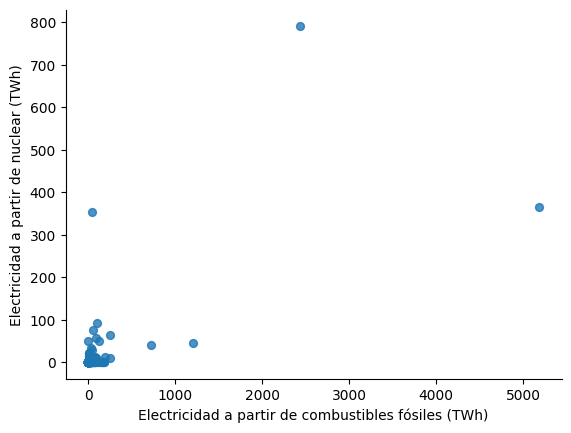

In [ ]:
# @title Electricidad a partir de combustibles fósiles (TWh) vs Electricidad a partir de nuclear (TWh)

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Electricidad a partir de combustibles fósiles (TWh)', y='Electricidad a partir de nuclear (TWh)', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

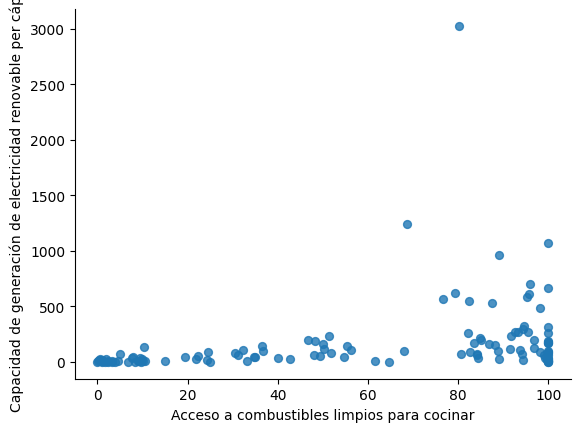

In [ ]:
# @title Acceso a combustibles limpios para cocinar vs Capacidad de generación de electricidad renovable per cápita

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Acceso a combustibles limpios para cocinar', y='Capacidad de generación de electricidad renovable per cápita', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

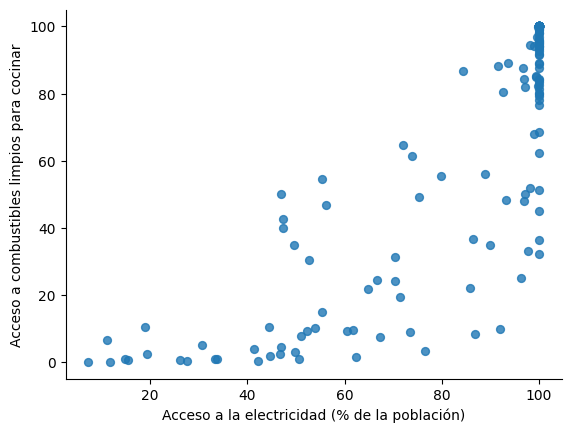

In [ ]:
# @title Acceso a la electricidad (% de la población) vs Acceso a combustibles limpios para cocinar

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Acceso a la electricidad (% de la población)', y='Acceso a combustibles limpios para cocinar', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

# Matriz de correlación

In [ ]:
df_filtered = df_limpio.drop(columns=['Latitud', 'Longitud', 'Año'])
matriz_correlacion = df_filtered.select_dtypes(include=['float64', 'int64']).corr()

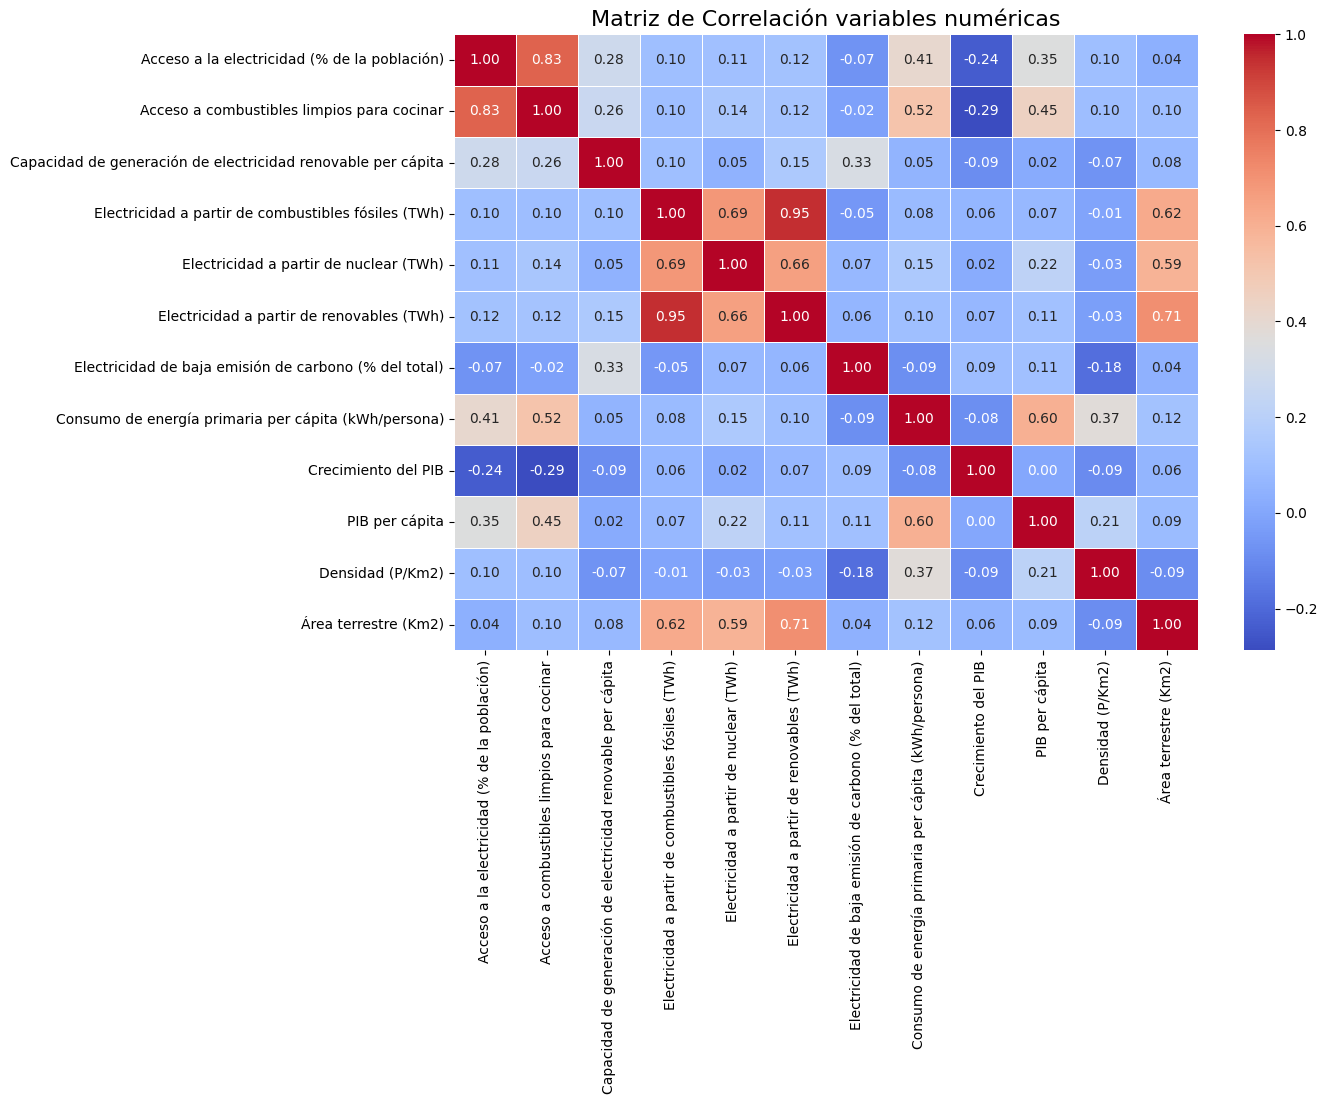

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title('Matriz de Correlación variables numéricas', fontsize=16)
plt.show()

# Regresión lineal simple

## Primera regresión lineal simple

## Gráfica

In [1]:
# Filtrar las columnas necesarias para la regresión
df_filtered = df[['Consumo de energía primaria per cápita (kWh/persona)', 'PIB per cápita']].dropna()

# Convertir el consumo de energía de kWh a TWh (1 TWh = 1,000,000,000 kWh)
df_filtered['Consumo de energía primaria per cápita (TWh/persona)'] = df_filtered['Consumo de energía primaria per cápita (kWh/persona)'] / 1e9

# Independiente (Consumo de energía primaria en TWh/persona)
X1 = df_filtered[['Consumo de energía primaria per cápita (TWh/persona)']]

# Dependiente (PIB per cápita)
y1 = df_filtered['PIB per cápita']

# Dividir los datos en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=11)

# Crear y entrenar el modelo
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X1_train, y1_train)

# Hacer predicciones
y1_pred = model.predict(X1_test)

# Visualizar los resultados
import matplotlib.pyplot as plt

plt.scatter(X1_test, y1_test, color='blue', label='Valores Reales')
plt.plot(X1_test, y1_pred, color='red', linewidth=2, label='Línea de Regresión')

plt.xlabel('Consumo de energía primaria per cápita (TWh/persona)')
plt.ylabel('PIB per cápita')
plt.title('Regresión Lineal: Consumo de energía (TWh/persona) vs PIB per cápita')
plt.grid(True)
plt.legend()

plt.show()


NameError: name 'df' is not defined

###  Valor de R² y p-value

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score
import statsmodels.api as sm

print(f'Valores R^2 y p-value')
r2 = r2_score(y1_test, y1_pred)
print(f' R^2: {r2}')


X1_train_sm = sm.add_constant(X1_train)


model_sm = sm.OLS(y1_train, X1_train_sm).fit()


print(model_sm.summary())


X1_train_sm = sm.add_constant(X1_train)


model_sm = sm.OLS(y1_train, X1_train_sm).fit()


print(model_sm.summary())



##Segunda regresión lineal simple

In [ ]:
# Filtrar las columnas necesarias para la regresión
df_filtered_combustibles = df[['Acceso a combustibles limpios para cocinar', 'PIB per cápita']].dropna()

# Independiente (Acceso a combustibles limpios para cocinar)
X2 = df_filtered_combustibles[['Acceso a combustibles limpios para cocinar']]

# Dependiente (PIB per cápita)
y2 = df_filtered_combustibles['PIB per cápita']


X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=11)


model_combustibles = LinearRegression()
model_combustibles.fit(X2_train, y2_train)


y2_pred = model_combustibles.predict(X2_test)

# Calcular R^2
r2_combustibles = r2_score(y2_test, y2_pred)
print(f'R^2: {r2_combustibles}')

# Visualizar los resultados
plt.scatter(X2_test, y2_test, color='blue', label='Valores Reales')
plt.plot(X2_test, y2_pred, color='red', linewidth=2, label='Línea de Regresión')

plt.xlabel('Acceso a combustibles limpios para cocinar (%)')
plt.ylabel('PIB per cápita')
plt.title('Regresión Lineal: Acceso a combustibles limpios vs PIB per cápita')
plt.grid(True)
plt.legend()

plt.show()

# Usar statsmodels para calcular el p-value
import statsmodels.api as sm

# Añadir una constante a los datos (necesario para statsmodels)
X2_train_sm = sm.add_constant(X2_train)

# Crear el modelo OLS (Ordinary Least Squares) y ajustarlo
model_combustibles_sm = sm.OLS(y2_train, X2_train_sm).fit()

# Obtener el resumen del modelo, que incluye los p-values
print(model_combustibles_sm.summary())


# Regresión lineal multiple

## Primera

R^2: 0.0980188015097393


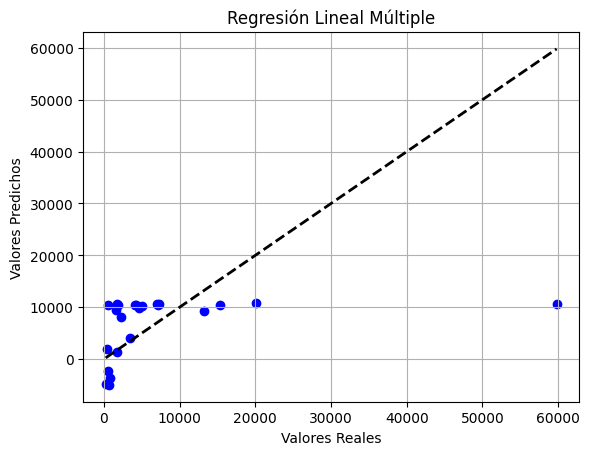

                            OLS Regression Results                            
Dep. Variable:         PIB per cápita   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     7.285
Date:                Fri, 25 Oct 2024   Prob (F-statistic):            0.00117
Time:                        23:18:02   Log-Likelihood:                -982.21
No. Observations:                  92   AIC:                             1970.
Df Residuals:                      89   BIC:                             1978.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [ ]:

df_filtered_multiple = df[['Acceso a la electricidad (% de la población)',
                           'Capacidad de generación de electricidad renovable per cápita',
                           'PIB per cápita']].dropna()

X_multiple = df_filtered_multiple[['Acceso a la electricidad (% de la población)',
                                   'Capacidad de generación de electricidad renovable per cápita']]


y_multiple = df_filtered_multiple['PIB per cápita']


X_multiple_train, X_multiple_test, y_multiple_train, y_multiple_test = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=11)


model_multiple = LinearRegression()
model_multiple.fit(X_multiple_train, y_multiple_train)


y_multiple_pred = model_multiple.predict(X_multiple_test)


r2_multiple = r2_score(y_multiple_test, y_multiple_pred)
print(f'R^2: {r2_multiple}')


plt.scatter(y_multiple_test, y_multiple_pred, color='blue')
plt.plot([y_multiple_test.min(), y_multiple_test.max()], [y_multiple_test.min(), y_multiple_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Lineal Múltiple')
plt.grid(True)
plt.show()


X_multiple_train_sm = sm.add_constant(X_multiple_train)  # Añadir constante para statsmodels


model_multiple_sm = sm.OLS(y_multiple_train, X_multiple_train_sm).fit()

print(model_multiple_sm.summary())


## Segunda

R^2: 0.2620897724810759


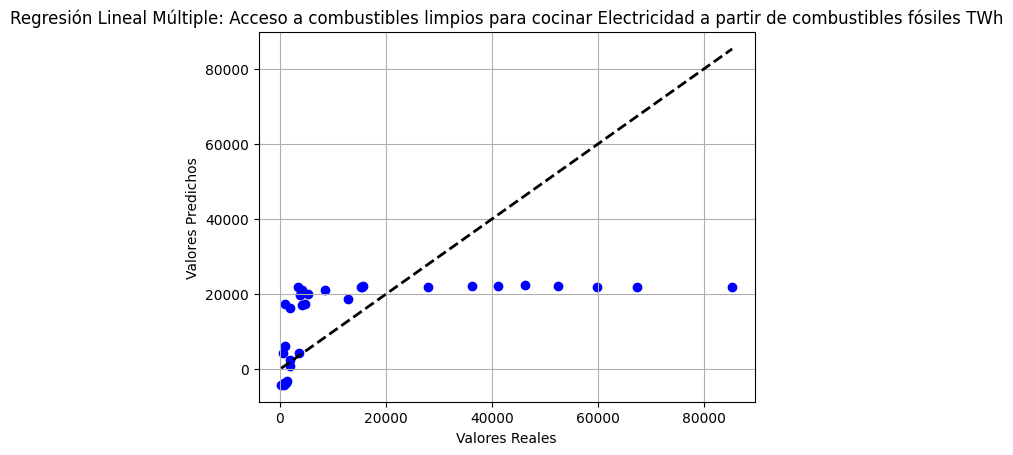

                            OLS Regression Results                            
Dep. Variable:         PIB per cápita   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.256
Method:                 Least Squares   F-statistic:                     21.68
Date:                Fri, 25 Oct 2024   Prob (F-statistic):           9.55e-09
Time:                        23:22:33   Log-Likelihood:                -1345.6
No. Observations:                 121   AIC:                             2697.
Df Residuals:                     118   BIC:                             2706.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------

In [ ]:
df_filtered_fossil_combustibles = df[['Acceso a combustibles limpios para cocinar',
                                      'Electricidad a partir de combustibles fósiles (TWh)',
                                      'PIB per cápita']].dropna()

# Variables independientes (Acceso a combustibles limpios y Electricidad a partir de combustibles fósiles)
X_multiple_fossil_combustibles = df_filtered_fossil_combustibles[['Acceso a combustibles limpios para cocinar',
                                                                  'Electricidad a partir de combustibles fósiles (TWh)']]


y_multiple_fossil_combustibles = df_filtered_fossil_combustibles['PIB per cápita']

# Dividir los datos en conjunto de entrenamiento y prueba
X_fossil_train, X_fossil_test, y_fossil_train, y_fossil_test = train_test_split(X_multiple_fossil_combustibles,
                                                                                y_multiple_fossil_combustibles,
                                                                                test_size=0.2, random_state=11)

# Crear y entrenar el modelo
model_fossil = LinearRegression()
model_fossil.fit(X_fossil_train, y_fossil_train)


y_fossil_pred = model_fossil.predict(X_fossil_test)

# Calcular R^2
r2_fossil = r2_score(y_fossil_test, y_fossil_pred)
print(f'R^2: {r2_fossil}')

# Visualizar los resultados
plt.scatter(y_fossil_test, y_fossil_pred, color='blue')
plt.plot([y_fossil_test.min(), y_fossil_test.max()], [y_fossil_test.min(), y_fossil_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión Lineal Múltiple: Acceso a combustibles limpios para cocinar Electricidad a partir de combustibles fósiles TWh')
plt.grid(True)
plt.show()


X_fossil_train_sm = sm.add_constant(X_fossil_train)  # Añadir constante para statsmodels


model_fossil_sm = sm.OLS(y_fossil_train, X_fossil_train_sm).fit()

# Obtener el resumen del modelo, que incluye los p-values
print(model_fossil_sm.summary())


# Transformación de coordenadas

In [ ]:
df['Coordenadas'] = df['Latitud'].astype(str) + ', ' + df['Longitud'].astype(str)

df_limpio = df.drop(columns=['Latitud','Longitud'])

df_limpio.head()


,Entidad,Año,Acceso a la electricidad (% de la población),Acceso a combustibles limpios para cocinar,Capacidad de generación de electricidad renovable per cápita,Electricidad a partir de combustibles fósiles (TWh),Electricidad a partir de nuclear (TWh),Electricidad a partir de renovables (TWh),Electricidad de baja emisión de carbono (% del total),Consumo de energía primaria per cápita (kWh/persona),Crecimiento del PIB,PIB per cápita,Densidad (P/Km2),Área terrestre (Km2),Coordenadas
0,Afghanistan,2020,97.70000,33.2,9.35,0.12,0.0,0.68,85.000000,702.888,-2.351101,516.747871,60,652230,"33.93911, 67.709953"
1,Albania,2020,100.00000,81.3,NaN,0.00,0.0,5.31,100.000000,11158.003,-3.955398,5246.292306,105,28748,"41.153332, 20.168331"
2,Algeria,2020,99.80413,99.7,15.64,72.01,0.0,0.72,0.989963,14933.807,-5.100000,3306.858208,18,2381741,"28.033886, 1.659626"
3,Angola,2020,46.89061,50.2,115.43,4.49,0.0,12.10,72.935500,3527.160,-5.399987,1776.166868,26,1246700,"-11.202692, 17.873887"
4,Antigua and Barbuda,2020,100.00000,100.0,167.98,0.31,0.0,0.02,6.060606,27785.227,-20.192371,13992.744480,223,443,"17.060816, -61.796428"


## Descarga y guardado

In [ ]:
##Guardar y descargar el archivo en Excel
output_final_path = 'ModificacionDatasetCord.xlsx'
df_limpio.to_excel(output_final_path, index=False)

from google.colab import files

# Descarga
files.download(output_final_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>